## Principal Component Analysis (PCA)

In [5]:
import numpy as np

X= np.random.rand(100,3)**2 + 0.05 *np.random.randn(100, 1)
X_centered= X - X.mean(axis= 0)
U, s, Vt = np.linalg.svd(X_centered)
Vt

array([[ 0.77211663,  0.46803749,  0.42985674],
       [ 0.63116871, -0.64347932, -0.43308246],
       [-0.0739051 , -0.6057023 ,  0.7922517 ]])

In [6]:
c1= Vt[0] 
c2= Vt[1]

In [8]:
W2 = Vt[:2].T
X2D= X_centered @ W2

In [10]:
X[:5]

array([[ 2.68639248e-01,  9.73380164e-01,  5.49743326e-01],
       [-9.19825468e-04, -2.76471662e-02, -2.06112220e-02],
       [ 6.67961060e-01,  7.93228258e-01,  1.42163352e-01],
       [ 4.95339746e-02, -1.64467179e-02,  7.19962695e-01],
       [ 6.45869168e-02,  9.75783005e-01,  9.07956672e-01]])

In [11]:
X2D[:5]

array([[ 0.33757019, -0.60186169],
       [-0.58424992,  0.11915199],
       [ 0.38637435, -0.05738249],
       [-0.22171078, -0.17693998],
       [ 0.33512303, -0.88733524]])

In [12]:
from sklearn.decomposition import PCA

pca= PCA(n_components=2)
X2D= pca.fit_transform(X)

In [13]:
pca.components_

array([[ 0.77211663,  0.46803749,  0.42985674],
       [-0.63116871,  0.64347932,  0.43308246]])

Clearly **PCA components** is the same as our **W2**

In [14]:
pca.explained_variance_ratio_

array([0.37765485, 0.32136743])

we have generated a completely random 3 feature dataset.. that's why correlation would always be less.. its ~33% in each

### On the MNIST dataset

In [15]:
from sklearn.datasets import fetch_openml

mnist= fetch_openml("mnist_784", as_frame= False)
X_train, y_train= mnist.data[:60000], mnist.target[:60000]
X_test, y_test  = mnist.data[60000: ], mnist.target[60000: ]

pca= PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)

In [21]:
d= np.argmax(cumsum>= 0.95)+1

In [22]:
d # Minimum no of feature needed to have a 95% coverage of varience 

154

1/5th of the dataset ... huh

In [24]:
pca= PCA(n_components=0.95)
X_reduced= pca.fit_transform(X_train)
pca.n_components_

154

In [27]:
cumsum.reshape(-1,1)

array([[0.09704664],
       [0.16800588],
       [0.22969677],
       [0.28359097],
       [0.33227894],
       [0.37540125],
       [0.40812055],
       [0.4369595 ],
       [0.4645798 ],
       [0.4881498 ],
       [0.5092417 ],
       [0.52947161],
       [0.54662979],
       [0.56355091],
       [0.57933732],
       [0.59416685],
       [0.60741246],
       [0.62018143],
       [0.63205406],
       [0.6435809 ],
       [0.65424256],
       [0.66430969],
       [0.67384542],
       [0.68297086],
       [0.69180491],
       [0.7001981 ],
       [0.70832389],
       [0.71618755],
       [0.72363488],
       [0.73054347],
       [0.73712441],
       [0.74360589],
       [0.74963204],
       [0.75549786],
       [0.76119807],
       [0.76663435],
       [0.77169222],
       [0.7765708 ],
       [0.7813851 ],
       [0.78610776],
       [0.79067523],
       [0.79512359],
       [0.7993086 ],
       [0.80329076],
       [0.8071405 ],
       [0.81089154],
       [0.81451162],
       [0.818

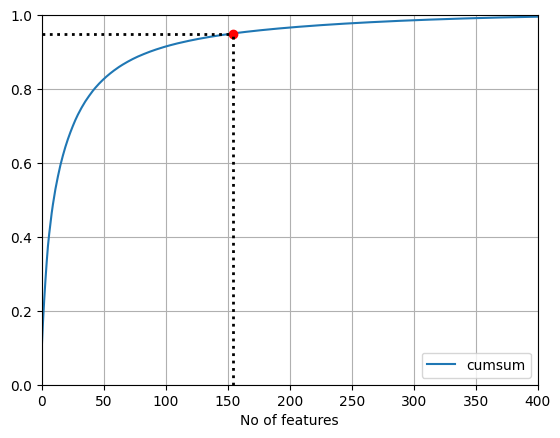

In [61]:
import matplotlib.pyplot as plt

x1= np.linspace(0, 401, 400)
plt.plot(x1, cumsum.reshape(-1,1)[:400], label= "cumsum")
plt.plot(154, 0.95, "ro")
plt.vlines(154, 0, 0.95, colors= "black", linewidth= 2, linestyles="dotted")
plt.hlines(0.95, 0, 154, colors= "black", linewidth= 2, linestyles="dotted")
plt.xlim(0, 400)
plt.ylim(0.0, 1.0)
plt.xlabel("No of features")

plt.legend(loc ="lower right")
plt.grid()